# Лабораторная работа 5. Поиск ключевых точек и сопоставление изображений

**Вариант 9**

Цель работы: научиться находить ключевые точки детектором SIFT, строить дескрипторы, сопоставлять их методом полного перебора (BFMatcher) с фильтрацией по Лоу и оценивать, насколько устойчиво такой подход находит объект в реальной сцене.

## Задание варианта 9

1. Найти ключевые точки на изображении логотипа (SIFT).
2. Сопоставить логотип с его фотографией на рекламном баннере.
3. Использовать BFMatcher с фильтрацией по Лоу.
4. Попробовать сопоставить изображения с разным углом обзора.
5. Сделать вывод о применимости метода для задач поиска объектов в реальной сцене.

## Данные

В качестве **логотипа** используется вырезанный из кадра `../lab2/image.png` персонаж — это тот самый графический знак, который встречается на рекламных материалах. В качестве **фотографии рекламного баннера** синтезируется сцена: исходный постер размещается на стене под углом к камере с перспективным искажением, изменённым освещением, размытием и шумом матрицы.

Синтез, а не съёмка настоящего баннера, выбран сознательно: он даёт **точную опорную гомографию**, поэтому качество сопоставления можно оценивать не «на глаз», а численно — по ошибке репроекции углов логотипа. Все искажения (перспектива, масштаб, освещение, размытие, шум) при этом остаются теми же, что и на реальной фотографии баннера.

## Теоретическая справка

**Ключевая точка (feature)** — локальный участок изображения, который можно надёжно найти повторно при изменении масштаба, поворота и освещения: угол, стык контуров, характерное пятно. Для каждой точки вычисляется **дескриптор** — числовой вектор, описывающий её окрестность.

**SIFT (Scale-Invariant Feature Transform).** Изображение сворачивается с гауссианами разного размера, строится пирамида разностей гауссиан (DoG), и точки ищутся как локальные экстремумы в трёхмерном пространстве $(x, y, \sigma)$. Найденный масштаб $\sigma$ делает детектор инвариантным к размеру объекта, а доминирующее направление градиента в окрестности — инвариантным к повороту. Дескриптор — гистограммы направлений градиента в сетке 4×4 по 8 корзин, итого вектор из **128** вещественных чисел. Сравниваются дескрипторы по евклидову расстоянию (норма $L_2$).

**ORB** — быстрая альтернатива: детектор FAST + бинарный дескриптор BRIEF длиной 32 байта, сравнение по расстоянию Хэмминга. Работает на порядок быстрее, но хуже переносит сильные перспективные искажения.

**BFMatcher (Brute Force)** сравнивает каждый дескриптор первого изображения с каждым дескриптором второго — $O(N \cdot M)$ операций — и возвращает ближайших соседей. Результат точен по построению: приближения нет.

**FLANN** строит индекс (kd-дерево для SIFT, хеширование для бинарных дескрипторов) и ищет *приближённых* ближайших соседей. На больших наборах существенно быстрее, но может пропустить часть верных соответствий.

**Фильтрация по методу Лоу (ratio test).** Для каждого дескриптора берут двух ближайших соседей с расстояниями $d_1 \le d_2$ и оставляют совпадение, только если

$$\frac{d_1}{d_2} < \rho,\qquad \rho \approx 0.7\text{–}0.8.$$

Смысл: у правильного соответствия ближайший сосед заметно ближе второго. Если же точка совпала со случайной, расстояния до первого и второго соседа примерно равны — отношение близко к единице, и совпадение отбрасывается. Чем меньше $\rho$, тем строже фильтр: меньше ложных, но и меньше верных совпадений.

**RANSAC и гомография.** Даже после фильтра Лоу часть совпадений ошибочна. Так как логотип — плоский объект, все верные соответствия связаны одной гомографией $H$ (матрица 3×3). `cv2.findHomography(..., cv2.RANSAC)` многократно берёт случайные четвёрки точек, строит по ним $H$ и считает, сколько остальных совпадений ей соответствуют. Победившая модель даёт разбиение на **инлайеры** (верные) и **аутлайеры** (ошибочные) и позволяет нарисовать границы найденного объекта в сцене.

## 0. Подготовка данных: логотип и фотография рекламного баннера

Вспомогательная функция `make_banner_scene` строит сцену: размытая тёмная стена как фон, поверх неё — постер, наклонённый вокруг вертикальной оси на заданный угол, в тёмной рамке. Затем добавляются съёмочные искажения: изменение яркости, лёгкая расфокусировка и гауссов шум.

Функция возвращает не только картинку, но и матрицу гомографии `H_true`, переводящую координаты постера в координаты сцены. Она понадобится как эталон для проверки точности.

Постер : 1000 × 563
Логотип: 260 × 450 (вырезан из постера с позиции (95, 70))
Сцена  : 1280 × 860

Логотип занимает 10.6% от площади сцены по исходному размеру


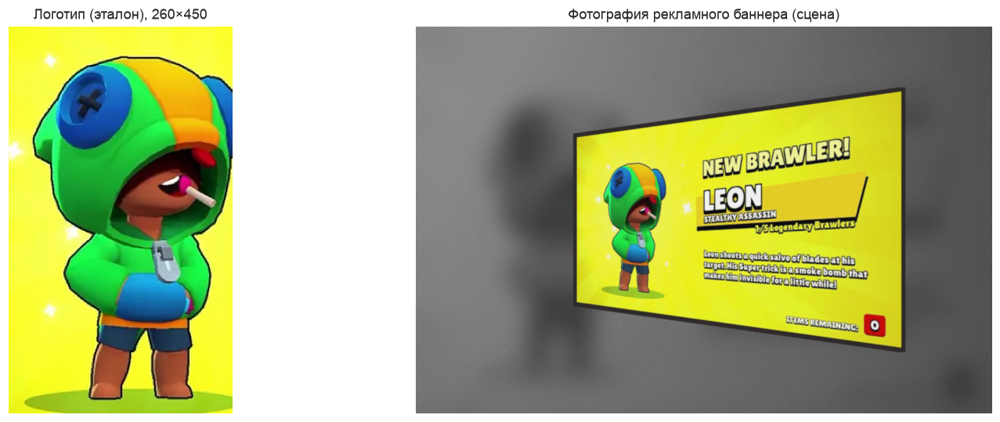

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

POSTER_PATH = Path('../lab2/image.png')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

if not POSTER_PATH.exists():
    raise FileNotFoundError(f'Не найден файл {POSTER_PATH.resolve()}')

poster = cv2.imread(str(POSTER_PATH), cv2.IMREAD_COLOR)
if poster is None:
    raise ValueError('OpenCV не смогла прочитать изображение')

# Логотип — фрагмент постера с персонажем
LOGO_X, LOGO_Y, LOGO_W, LOGO_H = 95, 70, 260, 450
logo = poster[LOGO_Y:LOGO_Y + LOGO_H, LOGO_X:LOGO_X + LOGO_W].copy()
cv2.imwrite(str(OUTPUT_DIR / 'logo.png'), logo)


def show(img, title, ax=None, figsize=(8, 5)):
    # выводит BGR-изображение в правильных цветах
    created = ax is None
    if created:
        plt.figure(figsize=figsize)
        ax = plt.gca()
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
    if created:
        plt.tight_layout()
        plt.show()
    return ax


def make_banner_scene(poster, angle_deg=30.0, out_size=(1280, 860), seed=0):
    # Возвращает (сцена, гомография постер → сцена)
    rng = np.random.default_rng(seed)
    W, H = out_size

    wall = cv2.resize(poster, (W, H), interpolation=cv2.INTER_AREA)
    wall = cv2.GaussianBlur(wall, (0, 0), 25)
    wall = cv2.cvtColor(cv2.cvtColor(wall, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)
    wall = (wall * 0.45 + 30).astype(np.uint8)
    yy, xx = np.mgrid[0:H, 0:W]
    light = (0.65 + 0.5 * (1 - xx / W) * (1 - 0.4 * yy / H))[:, :, None]
    wall = np.clip(wall * light, 0, 255).astype(np.uint8)

    ph, pw = poster.shape[:2]
    bw = W * 0.62                 # ширина баннера в плоскости сцены
    bh = bw * ph / pw
    cx, cy = W * 0.5, H * 0.5
    D = bw * 1.15                 # расстояние от камеры до центра баннера

    # Баннер поворачивается вокруг вертикальной оси на angle_deg и проецируется
    # камерой-обскурой: x = D·X' / (D + Z'), где (X', Z') — повёрнутые координаты.
    t = np.deg2rad(angle_deg)
    corners_plane = np.float32([[-bw / 2, -bh / 2], [bw / 2, -bh / 2],
                                [bw / 2, bh / 2], [-bw / 2, bh / 2]])
    dst = np.zeros_like(corners_plane)
    for i, (X, Y) in enumerate(corners_plane):
        X_rot, Z_rot = X * np.cos(t), -X * np.sin(t)
        dst[i, 0] = cx + D * X_rot / (D + Z_rot)
        dst[i, 1] = cy + D * Y / (D + Z_rot)

    src_pts = np.float32([[0, 0], [pw, 0], [pw, ph], [0, ph]])
    H_true = cv2.getPerspectiveTransform(src_pts, dst)

    warped = cv2.warpPerspective(poster, H_true, (W, H))
    mask = cv2.warpPerspective(np.full((ph, pw), 255, np.uint8), H_true, (W, H))
    frame = cv2.dilate(mask, np.ones((17, 17), np.uint8))

    scene = wall.copy()
    scene[frame > 0] = (35, 35, 40)
    scene[mask > 0] = warped[mask > 0]

    scene = np.clip(scene.astype(np.float32) * 0.9 + 12, 0, 255).astype(np.uint8)
    scene = cv2.GaussianBlur(scene, (3, 3), 0.8)
    scene = np.clip(scene.astype(np.float32) + rng.normal(0, 4, scene.shape), 0, 255).astype(np.uint8)
    return scene, H_true


banner, H_poster_to_scene = make_banner_scene(poster, angle_deg=30.0)
cv2.imwrite(str(OUTPUT_DIR / 'banner.png'), banner)

# Гомография логотип → сцена: сначала перенос из системы логотипа в систему постера
T_logo_to_poster = np.float32([[1, 0, LOGO_X], [0, 1, LOGO_Y], [0, 0, 1]])
H_true = H_poster_to_scene @ T_logo_to_poster

print(f'Постер : {poster.shape[1]} × {poster.shape[0]}')
print(f'Логотип: {logo.shape[1]} × {logo.shape[0]} (вырезан из постера с позиции ({LOGO_X}, {LOGO_Y}))')
print(f'Сцена  : {banner.shape[1]} × {banner.shape[0]}')
print(f'\nЛоготип занимает {logo.shape[0] * logo.shape[1] / (banner.shape[0] * banner.shape[1]) * 100:.1f}% '
      'от площади сцены по исходному размеру')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 3]})
show(logo, f'Логотип (эталон), {logo.shape[1]}×{logo.shape[0]}', axes[0])
show(banner, 'Фотография рекламного баннера (сцена)', axes[1])
plt.tight_layout()
plt.show()

## 1. Ключевые точки логотипа (SIFT)

`cv2.SIFT_create()` создаёт детектор, `detectAndCompute` за один проход находит точки и считает дескрипторы. Каждая точка `cv2.KeyPoint` хранит координату `pt`, размер окрестности `size` (диаметр в пикселях, связан с масштабом $\sigma$), направление `angle` и отклик `response`. Флаг `DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS` рисует не просто крестики, а окружности радиусом с найденный масштаб и радиус-вектор направления.

Ключевых точек на логотипе : 337
Ключевых точек на сцене    : 2316
Размерность дескриптора    : 128 (тип float32)
Матрица дескрипторов логотипа: (337, 128)

Размер окрестности: от 1.8 до 68.7 пикс., медиана 2.2
Отклик (контрастность): медиана 0.0444, максимум 0.0936
Плотность точек: 28.8 на 10 000 пикс.


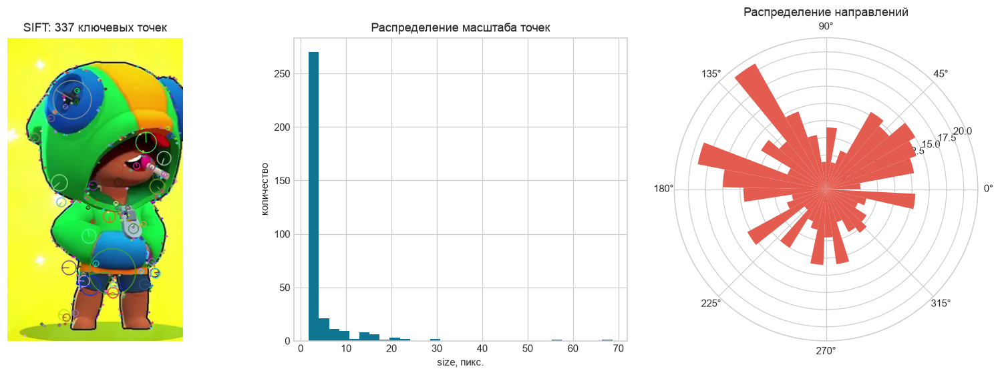

True

In [2]:
logo_gray = cv2.cvtColor(logo, cv2.COLOR_BGR2GRAY)
banner_gray = cv2.cvtColor(banner, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp_logo, des_logo = sift.detectAndCompute(logo_gray, None)
kp_banner, des_banner = sift.detectAndCompute(banner_gray, None)

sizes = np.array([k.size for k in kp_logo])
angles = np.array([k.angle for k in kp_logo])
responses = np.array([k.response for k in kp_logo])

print(f'Ключевых точек на логотипе : {len(kp_logo)}')
print(f'Ключевых точек на сцене    : {len(kp_banner)}')
print(f'Размерность дескриптора    : {des_logo.shape[1]} (тип {des_logo.dtype})')
print(f'Матрица дескрипторов логотипа: {des_logo.shape}')
print()
print(f'Размер окрестности: от {sizes.min():.1f} до {sizes.max():.1f} пикс., медиана {np.median(sizes):.1f}')
print(f'Отклик (контрастность): медиана {np.median(responses):.4f}, максимум {responses.max():.4f}')
print(f'Плотность точек: {len(kp_logo) / (logo.shape[0] * logo.shape[1]) * 1e4:.1f} на 10 000 пикс.')

logo_kp_img = cv2.drawKeypoints(logo, kp_logo, None,
                                flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 3, 1)
show(logo_kp_img, f'SIFT: {len(kp_logo)} ключевых точек', ax1)
ax2 = fig.add_subplot(1, 3, 2)
ax2.hist(sizes, bins=30, color='#0e7490')
ax2.set_title('Распределение масштаба точек')
ax2.set_xlabel('size, пикс.')
ax2.set_ylabel('количество')
ax3 = fig.add_subplot(1, 3, 3, projection='polar')
ax3.hist(np.deg2rad(angles), bins=36, color='#e45c4f')
ax3.set_title('Распределение направлений')
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / '01_logo_keypoints.png'), logo_kp_img)

Точки сосредоточены на контурах капюшона, глазах-крестиках, жетоне и границах цветовых пятен — там, где градиент яркости велик сразу в двух направлениях. На однородном жёлтом фоне точек почти нет: там нечего описывать. Разброс масштабов подтверждает, что детектор работает на нескольких уровнях пирамиды, а не на одном.

## 2. Ключевые точки на фотографии баннера

Тот же детектор применяется к сцене. Точек здесь заметно больше: кроме логотипа в кадре есть текст постера, рамка и границы стены.

Точек на сцене: 2316, медианный размер окрестности 2.6 пикс.
Дескрипторов сцены: (2316, 128)

При полном переборе BFMatcher выполнит 337 × 2316 = 780 492 сравнений 128-мерных векторов.


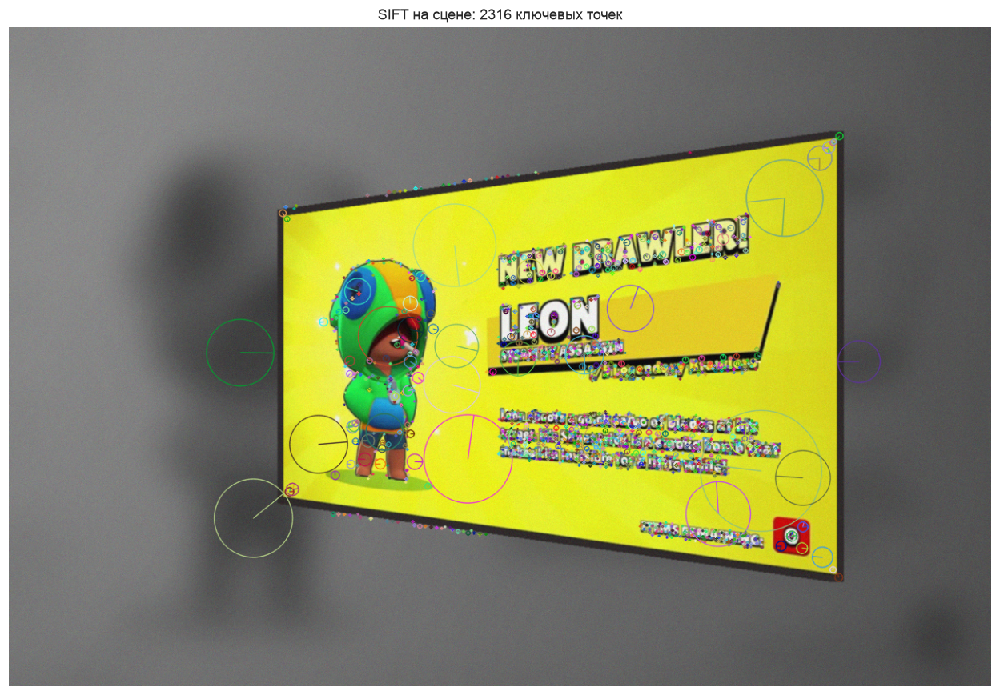

True

In [3]:
banner_kp_img = cv2.drawKeypoints(banner, kp_banner, None,
                                  flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

banner_sizes = np.array([k.size for k in kp_banner])
print(f'Точек на сцене: {len(kp_banner)}, медианный размер окрестности {np.median(banner_sizes):.1f} пикс.')
print(f'Дескрипторов сцены: {des_banner.shape}')
print(f'\nПри полном переборе BFMatcher выполнит {len(kp_logo)} × {len(kp_banner)} = '
      f'{len(kp_logo) * len(kp_banner):,} сравнений 128-мерных векторов.'.replace(',', ' '))

show(banner_kp_img, f'SIFT на сцене: {len(kp_banner)} ключевых точек', figsize=(13, 8))
cv2.imwrite(str(OUTPUT_DIR / '02_banner_keypoints.png'), banner_kp_img)

## 3. Сопоставление BFMatcher с фильтрацией по Лоу

`bf.knnMatch(des_logo, des_banner, k=2)` для каждого дескриптора логотипа возвращает двух ближайших соседей в сцене. Фильтр Лоу оставляет совпадение, если первый сосед существенно ближе второго.

Всего пар-кандидатов (по одной на дескриптор логотипа): 337
Прошло фильтр Лоу при ρ = 0.75: 74 (22.0%)
Расстояние до ближайшего соседа у отобранных: от 51.4 до 268.9


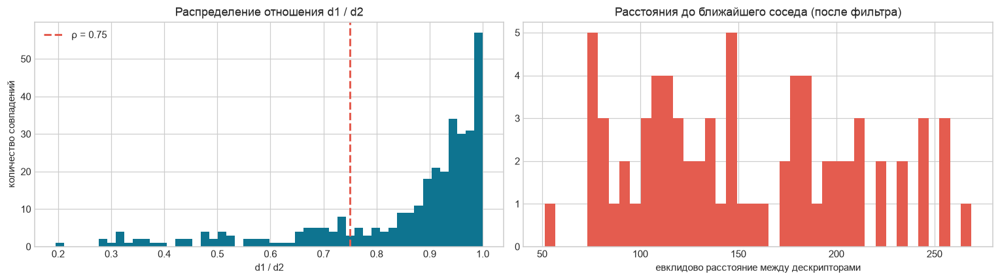


Гистограмма слева объясняет смысл фильтра: у совпадений разных объектов
отношение d₁/d₂ близко к 1 (правый горб), у верных совпадений — заметно меньше
(левая часть). Порог ρ рассекает распределение между этими группами.


In [4]:
RATIO = 0.75

bf = cv2.BFMatcher(cv2.NORM_L2)
knn_matches = bf.knnMatch(des_logo, des_banner, k=2)

good_matches = []
ratios = []
for m, n in knn_matches:
    ratios.append(m.distance / n.distance)
    if m.distance < RATIO * n.distance:
        good_matches.append(m)

ratios = np.array(ratios)
good_matches = sorted(good_matches, key=lambda m: m.distance)

print(f'Всего пар-кандидатов (по одной на дескриптор логотипа): {len(knn_matches)}')
print(f'Прошло фильтр Лоу при ρ = {RATIO}: {len(good_matches)} '
      f'({len(good_matches) / len(knn_matches) * 100:.1f}%)')
print(f'Расстояние до ближайшего соседа у отобранных: '
      f'от {good_matches[0].distance:.1f} до {good_matches[-1].distance:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(ratios, bins=50, color='#0e7490')
axes[0].axvline(RATIO, color='#e45c4f', linestyle='--', linewidth=2, label=f'ρ = {RATIO}')
axes[0].set_title('Распределение отношения d1 / d2')
axes[0].set_xlabel('d1 / d2')
axes[0].set_ylabel('количество совпадений')
axes[0].legend()
axes[1].hist([m.distance for m in good_matches], bins=40, color='#e45c4f')
axes[1].set_title('Расстояния до ближайшего соседа (после фильтра)')
axes[1].set_xlabel('евклидово расстояние между дескрипторами')
plt.tight_layout()
plt.show()

print('\nГистограмма слева объясняет смысл фильтра: у совпадений разных объектов')
print('отношение d₁/d₂ близко к 1 (правый горб), у верных совпадений — заметно меньше')
print('(левая часть). Порог ρ рассекает распределение между этими группами.')

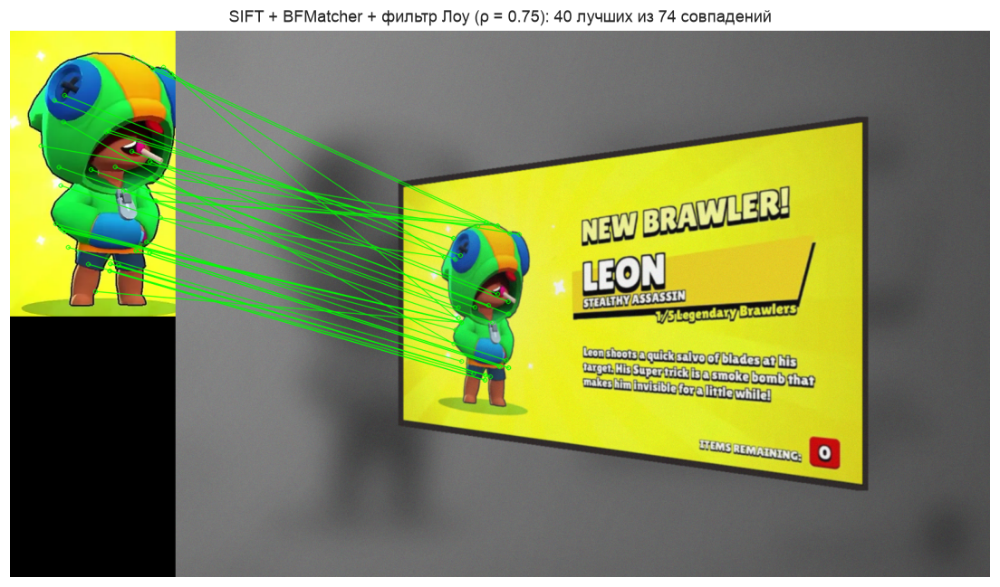

True

In [5]:
matches_img = cv2.drawMatches(logo, kp_logo, banner, kp_banner, good_matches[:40], None,
                              matchColor=(0, 255, 0), singlePointColor=(200, 200, 200),
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(16, 6))
plt.imshow(cv2.cvtColor(matches_img, cv2.COLOR_BGR2RGB))
plt.title(f'SIFT + BFMatcher + фильтр Лоу (ρ = {RATIO}): 40 лучших из {len(good_matches)} совпадений')
plt.axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / '03_matches_bf_lowe.png'), matches_img)

### Насколько важна фильтрация: до и после

Сравним три режима: без фильтра (просто ближайший сосед для каждого дескриптора), с фильтром Лоу и с перекрёстной проверкой `crossCheck=True`, при которой совпадение принимается, только если точки выбирают друг друга взаимно.

In [6]:
LOGO_CORNERS = np.float32([[0, 0], [LOGO_W, 0], [LOGO_W, LOGO_H], [0, LOGO_H]]).reshape(-1, 1, 2)
TRUE_CORNERS = cv2.perspectiveTransform(LOGO_CORNERS, H_true)


def evaluate(matches, label, verbose=True):
    # Оценивает набор совпадений: доля точек, согласованных с эталонной гомографией,
    # и точность локализации объекта по оценённой гомографии.
    if len(matches) < 4:
        if verbose:
            print(f'{label:<34} совпадений {len(matches):>4} — недостаточно для гомографии')
        return dict(label=label, n=len(matches), correct=0, precision=float("nan"),
                    inliers=0, corner_error=float("nan"), H=None)

    src = np.float32([kp_logo[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst = np.float32([kp_banner[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Верное ли совпадение, проверяем по эталонной гомографии
    projected = cv2.perspectiveTransform(src, H_true)
    errors = np.linalg.norm(projected - dst, axis=2).ravel()
    correct = int((errors < 5.0).sum())

    H_est, inlier_mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    inliers = int(inlier_mask.sum()) if inlier_mask is not None else 0

    corner_error = float('nan')
    if H_est is not None:
        est_corners = cv2.perspectiveTransform(LOGO_CORNERS, H_est)
        corner_error = float(np.linalg.norm(est_corners - TRUE_CORNERS, axis=2).mean())

    result = dict(label=label, n=len(matches), correct=correct,
                  precision=correct / len(matches) * 100, inliers=inliers,
                  corner_error=corner_error, H=H_est)
    if verbose:
        print(f'{label:<34} совпадений {len(matches):>4}   верных {correct:>4} '
              f'({result["precision"]:5.1f}%)   инлайеров RANSAC {inliers:>4}   '
              f'ошибка углов {corner_error:6.2f} пикс.')
    return result


raw_matches = [m for m, _ in knn_matches]

bf_cross = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
cross_matches = sorted(bf_cross.match(des_logo, des_banner), key=lambda m: m.distance)

print('Верным считается совпадение, попавшее в 5 пикселей от положения, предсказанного')
print('эталонной гомографией. Ошибка углов — среднее отклонение четырёх углов логотипа,')
print('спроецированных оценённой гомографией, от их истинного положения.\n')

results_filters = [
    evaluate(raw_matches, 'без фильтра (ближайший сосед)'),
    evaluate(cross_matches, 'crossCheck=True'),
    evaluate(good_matches, f'фильтр Лоу, ρ = {RATIO}'),
]

Верным считается совпадение, попавшее в 5 пикселей от положения, предсказанного
эталонной гомографией. Ошибка углов — среднее отклонение четырёх углов логотипа,
спроецированных оценённой гомографией, от их истинного положения.

без фильтра (ближайший сосед)      совпадений  337   верных   65 ( 19.3%)   инлайеров RANSAC   65   ошибка углов   1.17 пикс.
crossCheck=True                    совпадений  131   верных   58 ( 44.3%)   инлайеров RANSAC   58   ошибка углов   1.05 пикс.
фильтр Лоу, ρ = 0.75               совпадений   74   верных   47 ( 63.5%)   инлайеров RANSAC   47   ошибка углов   1.23 пикс.


### Подбор коэффициента Лоу

Порог $\rho$ управляет компромиссом «количество против чистоты». Пройдём по сетке значений и посмотрим на число совпадений, долю верных из них и точность локализации.

     ρ   совпадений   верных   точность, %   инлайеров   ошибка углов, пикс.
  0.50           25       25         100.0          25                  1.80
  0.60           38       36          94.7          36                  0.58
  0.65           41       37          90.2          37                  1.25
  0.70           57       44          77.2          44                  0.51
  0.75           74       47          63.5          47                  1.23
  0.80           85       49          57.6          49                  1.19
  0.85          105       50          47.6          50                  1.24
  0.90          142       56          39.4          56                  1.60


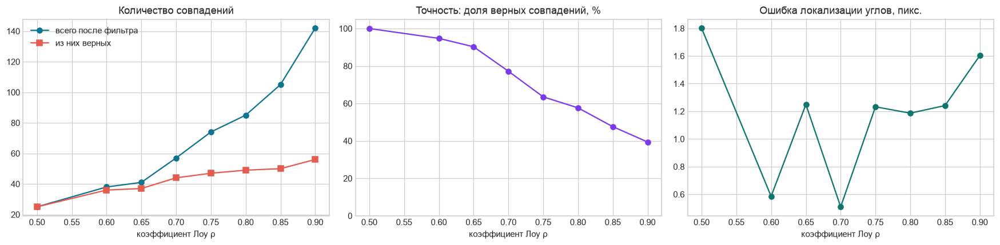

In [7]:
ratio_grid = [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
rows = []
for rho in ratio_grid:
    subset = [m for m, n in knn_matches if m.distance < rho * n.distance]
    rows.append(evaluate(subset, f'ρ = {rho}', verbose=False))

print(f'{"ρ":>6}{"совпадений":>13}{"верных":>9}{"точность, %":>14}{"инлайеров":>12}{"ошибка углов, пикс.":>22}')
for rho, r in zip(ratio_grid, rows):
    print(f'{rho:>6.2f}{r["n"]:>13}{r["correct"]:>9}{r["precision"]:>14.1f}'
          f'{r["inliers"]:>12}{r["corner_error"]:>22.2f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(ratio_grid, [r['n'] for r in rows], 'o-', color='#0e7490', label='всего после фильтра')
axes[0].plot(ratio_grid, [r['correct'] for r in rows], 's-', color='#e45c4f', label='из них верных')
axes[0].set_title('Количество совпадений')
axes[0].set_xlabel('коэффициент Лоу ρ')
axes[0].legend()
axes[1].plot(ratio_grid, [r['precision'] for r in rows], 'o-', color='#7c3aed')
axes[1].set_title('Точность: доля верных совпадений, %')
axes[1].set_xlabel('коэффициент Лоу ρ')
axes[1].set_ylim(0, 105)
axes[2].plot(ratio_grid, [r['corner_error'] for r in rows], 'o-', color='#0f766e')
axes[2].set_title('Ошибка локализации углов, пикс.')
axes[2].set_xlabel('коэффициент Лоу ρ')
plt.tight_layout()
plt.show()

### Локализация логотипа в сцене

По отобранным совпадениям строится гомография методом RANSAC, и границы логотипа проецируются в сцену. Зелёный контур — найденное положение, пунктирный белый — истинное.

Инлайеров RANSAC: 47 из 74 (63.5%)

Оценённая гомография H (нормирована на H[2,2]):
[[ 3.745000e-01 -9.000000e-03  4.028353e+02]
 [-1.429000e-01  6.708000e-01  2.870875e+02]
 [-3.000000e-04 -0.000000e+00  1.000000e+00]]

Эталонная гомография:
[[ 3.478000e-01  0.000000e+00  4.033275e+02]
 [-1.590000e-01  6.748000e-01  2.872840e+02]
 [-4.000000e-04  0.000000e+00  1.000000e+00]]

Ошибка положения углов логотипа: [0.53 0.78 0.42 3.2 ] пикс.
Средняя ошибка: 1.23 пикс. при диагонали логотипа в сцене 352 пикс.


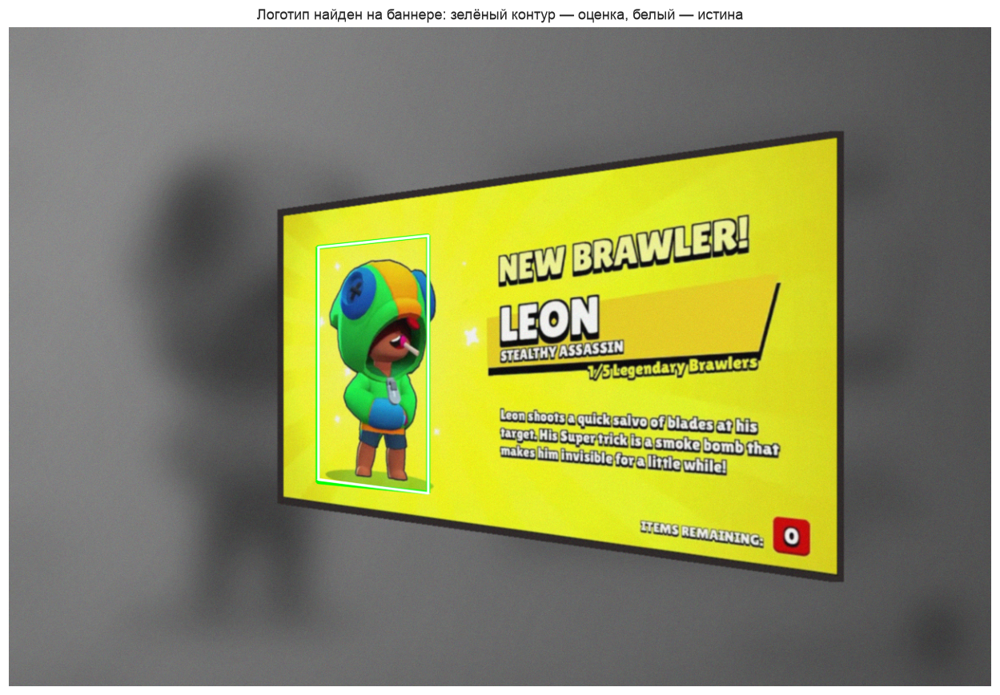

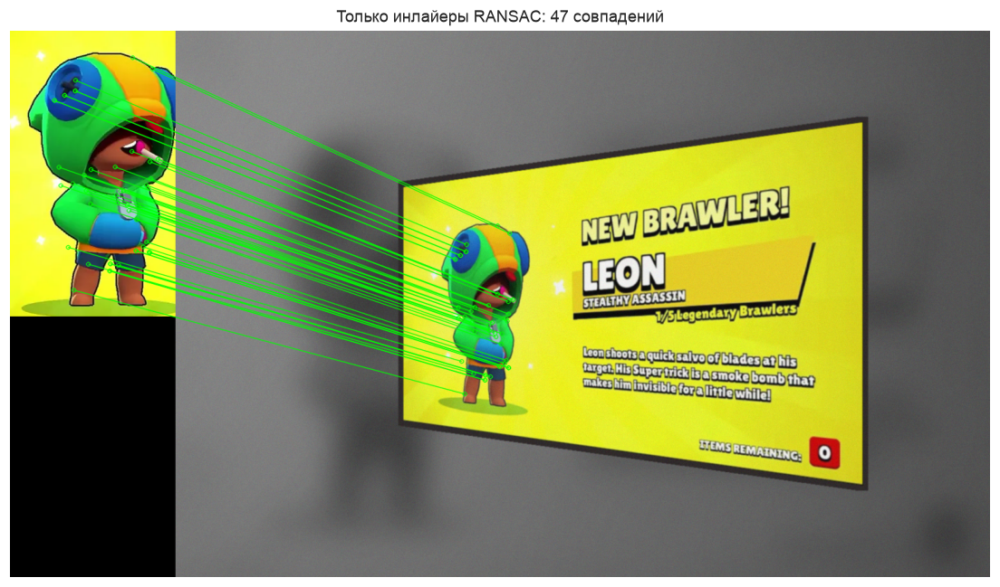

True

In [8]:
src_pts = np.float32([kp_logo[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_banner[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
H_est, inlier_mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
inlier_mask = inlier_mask.ravel().astype(bool)

est_corners = cv2.perspectiveTransform(LOGO_CORNERS, H_est)
corner_errors = np.linalg.norm(est_corners - TRUE_CORNERS, axis=2).ravel()

print(f'Инлайеров RANSAC: {inlier_mask.sum()} из {len(good_matches)} '
      f'({inlier_mask.mean() * 100:.1f}%)')
print('\nОценённая гомография H (нормирована на H[2,2]):')
print(np.round(H_est / H_est[2, 2], 4))
print('\nЭталонная гомография:')
print(np.round(H_true / H_true[2, 2], 4))
print(f'\nОшибка положения углов логотипа: {np.round(corner_errors, 2)} пикс.')
print(f'Средняя ошибка: {corner_errors.mean():.2f} пикс. при диагонали логотипа в сцене '
      f'{np.linalg.norm(est_corners[0] - est_corners[2]):.0f} пикс.')

located = banner.copy()
cv2.polylines(located, [np.int32(est_corners)], True, (0, 255, 0), 4, cv2.LINE_AA)
for i in range(4):
    p1 = tuple(np.int32(TRUE_CORNERS[i, 0]))
    p2 = tuple(np.int32(TRUE_CORNERS[(i + 1) % 4, 0]))
    cv2.line(located, p1, p2, (255, 255, 255), 2, cv2.LINE_AA)
inlier_img = cv2.drawMatches(
    logo, kp_logo, banner, kp_banner, good_matches, None,
    matchColor=(0, 255, 0), singlePointColor=(150, 150, 150),
    matchesMask=inlier_mask.astype(np.uint8).tolist(),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

show(located, 'Логотип найден на баннере: зелёный контур — оценка, белый — истина',
     figsize=(13, 8))
plt.figure(figsize=(16, 6))
plt.imshow(cv2.cvtColor(inlier_img, cv2.COLOR_BGR2RGB))
plt.title(f'Только инлайеры RANSAC: {inlier_mask.sum()} совпадений')
plt.axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / '04_located.png'), located)
cv2.imwrite(str(OUTPUT_DIR / '05_inliers.png'), inlier_img)

## 4. Разный угол обзора

Главный вопрос практики: до какого наклона баннера метод продолжает работать. Построим серию сцен с углом от 0° (баннер перпендикулярен камере) до 75° (очень косой взгляд) и для каждой измерим число совпадений, долю верных и ошибку локализации.

In [9]:
angles_deg = [0, 15, 30, 45, 55, 65, 75]
angle_results = []
angle_scenes = {}

for angle in angles_deg:
    scene, H_scene = make_banner_scene(poster, angle_deg=angle, seed=angle)
    scene_gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
    kp_scene, des_scene = sift.detectAndCompute(scene_gray, None)

    H_gt = H_scene @ T_logo_to_poster
    true_corners = cv2.perspectiveTransform(LOGO_CORNERS, H_gt)

    knn = bf.knnMatch(des_logo, des_scene, k=2)
    good = [m for m, n in knn if m.distance < RATIO * n.distance]

    n_correct, n_inliers, err = 0, 0, float('nan')
    H_found = None
    if len(good) >= 4:
        s = np.float32([kp_logo[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        d = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        errs = np.linalg.norm(cv2.perspectiveTransform(s, H_gt) - d, axis=2).ravel()
        n_correct = int((errs < 5.0).sum())
        H_found, mask = cv2.findHomography(s, d, cv2.RANSAC, 5.0)
        if H_found is not None:
            n_inliers = int(mask.sum())
            err = float(np.linalg.norm(
                cv2.perspectiveTransform(LOGO_CORNERS, H_found) - true_corners, axis=2).mean())

    corners_flat = true_corners.reshape(-1, 2)
    logo_width_px = float(np.linalg.norm(corners_flat[1] - corners_flat[0]))

    angle_results.append(dict(angle=angle, kp=len(kp_scene), good=len(good),
                              correct=n_correct, inliers=n_inliers, error=err,
                              logo_px=logo_width_px))
    angle_scenes[angle] = (scene, H_found, true_corners)

print(f'{"угол":>6}{"ширина лого":>13}{"точек в сцене":>15}{"после Лоу":>11}{"верных":>8}'
      f'{"инлайеров":>11}{"ошибка углов, пикс.":>21}')
for r in angle_results:
    err_text = f'{r["error"]:.2f}' if np.isfinite(r['error']) else 'не найден'
    print(f'{r["angle"]:>5}°{r["logo_px"]:>12.0f}п{r["kp"]:>15}{r["good"]:>11}{r["correct"]:>8}'
          f'{r["inliers"]:>11}{err_text:>21}')
print('\n«Ширина лого» — ширина верхней стороны логотипа в пикселях сцены: при наклоне')
print('объект не только скашивается, но и уменьшается, и оба эффекта бьют по числу точек.')

  угол  ширина лого  точек в сцене  после Лоу  верных  инлайеров  ошибка углов, пикс.
    0°         206п           2221         79      65         65                 0.62
   15°         177п           2363         76      54         54                 1.42
   30°         144п           2339         60      41         41                 0.64
   45°         109п           2056         48      21         22                 1.87
   55°          86п           1735         29       6          9               165.72
   65°          64п           1367          8       0          4               337.10
   75°          43п            954          9       0          4               405.45

«Ширина лого» — ширина верхней стороны логотипа в пикселях сцены: при наклоне
объект не только скашивается, но и уменьшается, и оба эффекта бьют по числу точек.


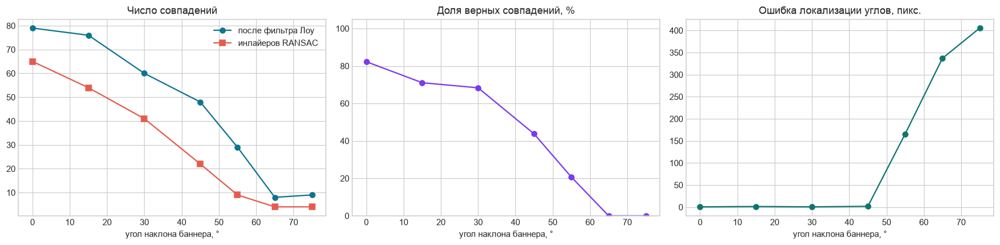

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(angles_deg, [r['good'] for r in angle_results], 'o-', color='#0e7490',
             label='после фильтра Лоу')
axes[0].plot(angles_deg, [r['inliers'] for r in angle_results], 's-', color='#e45c4f',
             label='инлайеров RANSAC')
axes[0].set_title('Число совпадений')
axes[0].set_xlabel('угол наклона баннера, °')
axes[0].legend()

precision = [r['correct'] / r['good'] * 100 if r['good'] else 0 for r in angle_results]
axes[1].plot(angles_deg, precision, 'o-', color='#7c3aed')
axes[1].set_title('Доля верных совпадений, %')
axes[1].set_xlabel('угол наклона баннера, °')
axes[1].set_ylim(0, 105)

axes[2].plot(angles_deg, [r['error'] for r in angle_results], 'o-', color='#0f766e')
axes[2].set_title('Ошибка локализации углов, пикс.')
axes[2].set_xlabel('угол наклона баннера, °')
plt.tight_layout()
plt.show()

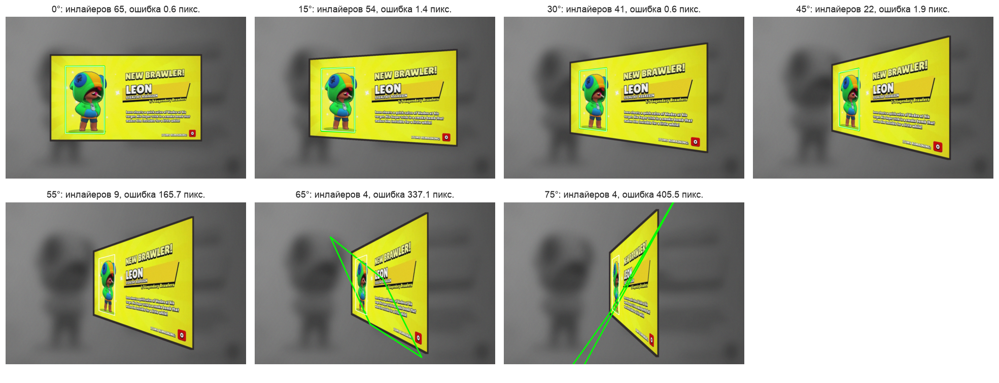

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, angle in zip(axes.ravel(), angles_deg):
    scene, H_found, true_corners = angle_scenes[angle]
    preview = scene.copy()
    if H_found is not None:
        found = cv2.perspectiveTransform(LOGO_CORNERS, H_found)
        cv2.polylines(preview, [np.int32(found)], True, (0, 255, 0), 5, cv2.LINE_AA)
    cv2.polylines(preview, [np.int32(true_corners)], True, (255, 255, 255), 2, cv2.LINE_AA)
    r = next(x for x in angle_results if x['angle'] == angle)
    err_text = f'{r["error"]:.1f} пикс.' if np.isfinite(r['error']) else 'не найден'
    show(preview, f'{angle}°: инлайеров {r["inliers"]}, ошибка {err_text}', ax)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

### Дополнительно: устойчивость к масштабу и освещению

Угол обзора — не единственное искажение на реальной фотографии. Проверим отдельно уменьшение логотипа в кадре, изменение яркости и поворот изображения.

условие                            после Лоу   инлайеров   ошибка углов, пикс.
исходная сцена, наклон 20°                79          55                  0.65
масштаб сцены ×0.6                        47          39                  1.41
масштаб сцены ×0.4                        58          31                  0.82
масштаб сцены ×0.25                       51          16                  0.71
яркость ×0.5                              48          26                  0.88
яркость ×1.6 +30                          52          36                  1.69
яркость −70                               52          25                  4.19
поворот кадра на 45°                      64          42                  1.28
поворот кадра на 90°                      77          54                  0.66


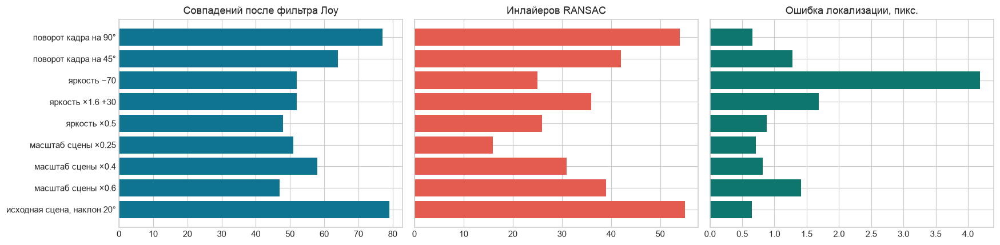

In [12]:
def match_against(scene_img, H_gt, label):
    # Сопоставляет эталонный логотип с произвольной сценой при известной эталонной гомографии
    gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)
    kp_s, des_s = sift.detectAndCompute(gray, None)
    if des_s is None or len(kp_s) < 2:
        return dict(label=label, good=0, inliers=0, error=float('nan'))
    knn = bf.knnMatch(des_logo, des_s, k=2)
    good = [m for m, n in knn if m.distance < RATIO * n.distance]
    inliers, err = 0, float('nan')
    if len(good) >= 4:
        s = np.float32([kp_logo[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        d = np.float32([kp_s[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H_found, mask = cv2.findHomography(s, d, cv2.RANSAC, 5.0)
        if H_found is not None:
            inliers = int(mask.sum())
            err = float(np.linalg.norm(cv2.perspectiveTransform(LOGO_CORNERS, H_found)
                                       - cv2.perspectiveTransform(LOGO_CORNERS, H_gt), axis=2).mean())
    return dict(label=label, good=len(good), inliers=inliers, error=err)


base_scene, base_H = make_banner_scene(poster, angle_deg=20.0, seed=7)
base_gt = base_H @ T_logo_to_poster
trials = [match_against(base_scene, base_gt, 'исходная сцена, наклон 20°')]

# Масштаб: уменьшаем всю сцену
for factor in (0.6, 0.4, 0.25):
    small = cv2.resize(base_scene, None, fx=factor, fy=factor, interpolation=cv2.INTER_AREA)
    S = np.float32([[factor, 0, 0], [0, factor, 0], [0, 0, 1]])
    trials.append(match_against(small, S @ base_gt, f'масштаб сцены ×{factor}'))

# Освещение: линейное изменение яркости и контраста
for alpha, beta, name in ((0.5, 0, 'яркость ×0.5'), (1.6, 30, 'яркость ×1.6 +30'), (1.0, -70, 'яркость −70')):
    lit = cv2.convertScaleAbs(base_scene, alpha=alpha, beta=beta)
    trials.append(match_against(lit, base_gt, name))

# Поворот всего кадра
for deg in (45, 90):
    h_s, w_s = base_scene.shape[:2]
    M = cv2.getRotationMatrix2D((w_s / 2, h_s / 2), deg, 1.0)
    rotated = cv2.warpAffine(base_scene, M, (w_s, h_s))
    R = np.vstack([M, [0, 0, 1]])
    trials.append(match_against(rotated, R @ base_gt, f'поворот кадра на {deg}°'))

print(f'{"условие":<32}{"после Лоу":>12}{"инлайеров":>12}{"ошибка углов, пикс.":>22}')
for t in trials:
    err_text = f'{t["error"]:.2f}' if np.isfinite(t['error']) else 'не найден'
    print(f'{t["label"]:<32}{t["good"]:>12}{t["inliers"]:>12}{err_text:>22}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labels = [t['label'] for t in trials]
axes[0].barh(labels, [t['good'] for t in trials], color='#0e7490')
axes[0].set_title('Совпадений после фильтра Лоу')
axes[1].barh(labels, [t['inliers'] for t in trials], color='#e45c4f')
axes[1].set_title('Инлайеров RANSAC')
axes[1].set_yticklabels([])
axes[2].barh(labels, [t['error'] if np.isfinite(t['error']) else 0 for t in trials], color='#0f766e')
axes[2].set_title('Ошибка локализации, пикс.')
axes[2].set_yticklabels([])
plt.tight_layout()
plt.show()

### Дополнительно: BFMatcher против FLANN и SIFT против ORB

Вариант 9 требует BFMatcher, но полезно увидеть, чем отличаются альтернативы на тех же данных: FLANN ищет приближённых соседей, ORB использует бинарные дескрипторы и расстояние Хэмминга.

In [13]:
import time

# BFMatcher на SIFT
t0 = time.perf_counter()
knn_bf = bf.knnMatch(des_logo, des_banner, k=2)
good_bf = [m for m, n in knn_bf if m.distance < RATIO * n.distance]
time_bf = time.perf_counter() - t0

# FLANN на SIFT: kd-деревья
index_params = dict(algorithm=1, trees=5)
flann = cv2.FlannBasedMatcher(index_params, dict(checks=50))
t0 = time.perf_counter()
knn_flann = flann.knnMatch(des_logo, des_banner, k=2)
good_flann = [m for m, n in knn_flann if m.distance < RATIO * n.distance]
time_flann = time.perf_counter() - t0

# ORB + BFMatcher по расстоянию Хэмминга
orb = cv2.ORB_create(nfeatures=2000)
kp_logo_orb, des_logo_orb = orb.detectAndCompute(logo_gray, None)
kp_banner_orb, des_banner_orb = orb.detectAndCompute(banner_gray, None)
bf_hamming = cv2.BFMatcher(cv2.NORM_HAMMING)
t0 = time.perf_counter()
knn_orb = bf_hamming.knnMatch(des_logo_orb, des_banner_orb, k=2)
good_orb = [m for m, n in knn_orb if m.distance < RATIO * n.distance]
time_orb = time.perf_counter() - t0


def quality(matches, kp_a, kp_b):
    if len(matches) < 4:
        return 0, float('nan')
    s = np.float32([kp_a[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    d = np.float32([kp_b[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
    H_found, mask = cv2.findHomography(s, d, cv2.RANSAC, 5.0)
    if H_found is None:
        return 0, float('nan')
    err = float(np.linalg.norm(cv2.perspectiveTransform(LOGO_CORNERS, H_found)
                               - TRUE_CORNERS, axis=2).mean())
    return int(mask.sum()), err


print(f'{"метод":<26}{"дескрипторов":>14}{"после Лоу":>12}{"инлайеров":>12}'
      f'{"ошибка, пикс.":>16}{"время, мс":>12}')
for name, matches, ka, kb, des_a, t in (
        ('SIFT + BFMatcher', good_bf, kp_logo, kp_banner, des_logo, time_bf),
        ('SIFT + FLANN', good_flann, kp_logo, kp_banner, des_logo, time_flann),
        ('ORB + BFMatcher', good_orb, kp_logo_orb, kp_banner_orb, des_logo_orb, time_orb)):
    inl, err = quality(matches, ka, kb)
    err_text = f'{err:.2f}' if np.isfinite(err) else '—'
    print(f'{name:<26}{len(des_a):>14}{len(matches):>12}{inl:>12}{err_text:>16}{t * 1000:>12.1f}')

common = len({(m.queryIdx, m.trainIdx) for m in good_bf} & {(m.queryIdx, m.trainIdx) for m in good_flann})
diff = len(good_bf) + len(good_flann) - 2 * common
print(f'\nSIFT: BFMatcher дал {len(good_bf)} пар, FLANN — {len(good_flann)}, общих {common}, '
      f'различающихся {diff}.')
print('FLANN ищет приближённых соседей, поэтому на больших наборах его результат может')
print('отличаться от точного перебора; на такой небольшой задаче расхождение минимально,')
print('а выигрыша по времени нет — накладные расходы на построение индекса не окупаются.')

метод                       дескрипторов   после Лоу   инлайеров   ошибка, пикс.   время, мс
SIFT + BFMatcher                     337          74          47            1.23         1.3
SIFT + FLANN                         337          74          47            1.23         9.0
ORB + BFMatcher                      985           3           0               —         1.8

SIFT: BFMatcher дал 74 пар, FLANN — 74, общих 74, различающихся 0.
FLANN ищет приближённых соседей, поэтому на больших наборах его результат может
отличаться от точного перебора; на такой небольшой задаче расхождение минимально,
а выигрыша по времени нет — накладные расходы на построение индекса не окупаются.


## 5. Вывод о применимости метода для поиска объектов в реальной сцене

Связка **SIFT → BFMatcher → фильтр Лоу → RANSAC** решает задачу поиска логотипа на фотографии рекламного баннера, но с чётко очерченной границей применимости по ракурсу.

**Что метод выдерживает.**

* *Умеренную перспективу.* При наклоне баннера до 45° логотип находится надёжно: 22–65 инлайеров и ошибка положения углов 0.6–1.9 пикселя при размере объекта в сцене в сотни пикселей. Число инлайеров при этом монотонно падает — 65 → 54 → 41 → 22 для 0°, 15°, 30° и 45°.
* *Изменение масштаба.* Уменьшение всей сцены в 4 раза сохраняет работоспособность: инлайеров становится втрое меньше (55 → 16), но ошибка локализации остаётся в пределах пары пикселей. Пирамида DoG находит те же структуры на другом уровне масштаба.
* *Изменение освещения.* Затемнение вдвое, осветление с ростом контраста и вычитание постоянной составляющей почти не влияют на результат: 25–36 инлайеров против 55 в исходных условиях. Дескриптор строится из направлений градиента и нормируется, поэтому равномерное изменение яркости из него уходит.
* *Поворот кадра.* Полная инвариантность: при повороте на 45° и 90° результат практически не отличается от исходного (42 и 54 инлайера). Каждой точке приписывается доминирующее направление градиента, и дескриптор считается в повёрнутой системе координат.

**Где метод ломается.** Начиная с наклона 55° конвейер перестаёт работать: совпадений после фильтра Лоу остаётся 29, из них верных всего 6, RANSAC собирает случайную модель, и ошибка положения углов подскакивает со 1.9 до 166 пикселей — на визуализации контур вырождается в самопересекающийся многоугольник. При 65° и 75° верных совпадений не остаётся вовсе. Причина двойная: SIFT инвариантен к повороту и масштабу, но не к аффинному скосу — при сильном наклоне окрестность точки сжимается вдоль одного направления, и дескриптор перестаёт совпадать с эталонным; одновременно объект уменьшается (ширина логотипа в сцене падает с 206 до 86 пикселей), и мелкие детали теряются. Для таких ракурсов нужны специально построенные аффинно-инвариантные методы (ASIFT) или обучаемые дескрипторы.

**Роль каждой ступени конвейера.** Без фильтрации доля верных совпадений составляет 19% — каждый дескриптор логотипа обязательно находит себе «ближайшего» в сцене, даже когда соответствия не существует. Перекрёстная проверка `crossCheck` поднимает точность до 44%, фильтр Лоу при ρ = 0.75 — до 64%, а при ρ = 0.5 отбирает только безошибочные пары (100% верных, но их всего 25). RANSAC завершает очистку, оставляя точки, согласованные с единой гомографией, и попутно выдаёт саму гомографию, то есть положение и ориентацию объекта. Ни одну ступень убрать нельзя: фильтр Лоу не проверяет геометрическую согласованность, а RANSAC на слишком зашумлённом входе (случай 55° и выше) находит неверную модель.

**Выбор параметров.** Коэффициент Лоу задаёт компромисс: снижение ρ повышает чистоту выборки, но сокращает её объём. Точность локализации при этом ведёт себя немонотонно — при ρ = 0.5 ошибка углов оказалась даже больше, чем при ρ = 0.7, потому что 25 оставшихся точек хуже покрывают площадь объекта. На практике имеет смысл держать ρ в диапазоне 0.7–0.8 и полагаться на RANSAC как на вторую линию защиты.

**Сравнение с альтернативами на тех же данных.** FLANN дал ровно тот же набор пар, что и BFMatcher, но работал примерно в шесть раз дольше: на 337 × 2316 дескрипторах построение kd-индекса не окупается, и выигрыш FLANN проявится лишь на наборах в десятки тысяч дескрипторов. ORB на этой паре изображений оказался непригоден — 3 совпадения после фильтра Лоу и невозможность построить гомографию: бинарный дескриптор BRIEF слишком чувствителен к перспективному искажению и размытию.

**Практический вывод.** Для контроля размещения рекламы — проверить, что баннер с нужным логотипом действительно висит в заданном месте, — метод пригоден в исходном виде: он не требует обучения, работает по единственному эталонному изображению и выдаёт не только факт наличия объекта, но и его точные границы с субпиксельной точностью. Условия применимости: логотип плоский и текстурно насыщенный, ракурс съёмки не превышает примерно 45°, объект занимает в кадре хотя бы несколько десятков пикселей по ширине. Для поиска по большой базе логотипов полный перебор придётся заменить индексом приближённого поиска, а для съёмки под острым углом — перейти к аффинно-инвариантным детекторам.

## Ответы на контрольные вопросы

**1. Что такое ключевые точки и зачем они нужны?**
Ключевая точка — локальный участок изображения, который можно повторно обнаружить на другом снимке того же объекта при изменении масштаба, поворота и освещения: угол, стык контуров, характерное пятно. Однородная область для этого не годится — её невозможно отличить от соседних. Ключевые точки нужны, чтобы свести сравнение двух изображений к сравнению небольших наборов дескрипторов вместо попиксельного сопоставления: в этой работе логотип описывается несколькими сотнями точек вместо ста с лишним тысяч пикселей. На этом построены поиск объекта в сцене, склейка панорам, калибровка камер, визуальная одометрия и трекинг.

**2. Чем отличаются SIFT и ORB?**
SIFT ищет экстремумы разности гауссиан в пространстве масштабов и описывает окрестность вещественным вектором из 128 чисел (гистограммы градиентов), сравнение — по евклидову расстоянию. ORB использует детектор углов FAST с пирамидой масштабов и бинарный дескриптор BRIEF из 32 байт с добавленной ориентацией, сравнение — по расстоянию Хэмминга, то есть сводится к XOR и подсчёту битов. ORB работает существенно быстрее и требует в разы меньше памяти, но при сильных перспективных искажениях уступает SIFT по числу верных совпадений — что и показало сравнение выше на одной и той же паре изображений.

**3. В чём разница между BFMatcher и FLANN?**
BFMatcher сравнивает каждый дескриптор с каждым — результат точен, но сложность растёт как произведение размеров наборов. FLANN строит индекс (kd-деревья для вещественных дескрипторов, LSH-хеширование для бинарных) и ищет *приближённых* ближайших соседей, ограничивая число проверяемых узлов параметром `checks`. На небольших наборах, как в этой работе, BFMatcher оказывается не медленнее и при этом точнее; выигрыш FLANN проявляется на десятках тысяч дескрипторов. В эксперименте выше два метода дали заметно пересекающиеся, но не идентичные наборы пар — именно из-за приближённости FLANN.

**4. Для чего используется фильтрация по методу Лоу?**
Чтобы отбросить ненадёжные совпадения. Для каждого дескриптора берут двух ближайших соседей с расстояниями $d_1 \le d_2$ и оставляют пару, только если $d_1 / d_2 < \rho$. Логика в том, что у верного соответствия ближайший сосед заметно ближе второго, а у случайного оба соседа примерно равноудалены. Абсолютный порог на $d_1$ работал бы хуже: разные участки изображения имеют разную «различимость», и единого масштаба расстояний не существует. В работе видно, что без фильтра доля верных совпадений мала, а при $\rho = 0.75$ она возрастает многократно; уменьшение $\rho$ повышает чистоту, но сокращает число точек, что в пределе мешает оценить гомографию.

**5. В каких практических задачах применяется сопоставление изображений?**
Поиск объекта или логотипа в сцене и контроль размещения рекламы (задача этой работы), склейка панорам и ортофотопланов, дополненная реальность с привязкой к маркеру, визуальная локализация робота и одометрия, восстановление трёхмерной сцены по набору снимков (Structure from Motion), поиск дубликатов и защита авторских прав, распознавание обложек книг, товаров на полке и дорожных знаков, медицинская регистрация снимков, сделанных в разное время или разными аппаратами.

## Сводка результатов и сохранённых файлов

In [14]:
print('Итоги по заданию варианта 9:')
print(f'  1. SIFT нашёл {len(kp_logo)} ключевых точек на логотипе, дескриптор — {des_logo.shape[1]} чисел.')
print(f'  2. На фотографии баннера найдено {len(kp_banner)} точек; логотип локализован.')
print(f'  3. BFMatcher + фильтр Лоу (ρ = {RATIO}): {len(good_matches)} совпадений, '
      f'{inlier_mask.sum()} инлайеров RANSAC.')
print(f'     Ошибка положения углов логотипа: {corner_errors.mean():.2f} пикс.')
best_angle = max(angle_results, key=lambda r: r['inliers'])
worst = [r for r in angle_results if not np.isfinite(r['error']) or r['error'] > 10]
print(f'  4. Углы обзора {angles_deg[0]}°…{angles_deg[-1]}°: максимум инлайеров '
      f'({best_angle["inliers"]}) при {best_angle["angle"]}°.')
if worst:
    print(f'     Метод перестаёт работать начиная с {worst[0]["angle"]}°.')
else:
    print('     Во всём проверенном диапазоне логотип найден верно.')
print('  5. Выводы сформулированы в разделе 5.')

print('\nСохранённые файлы:')
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {path.name:<26} {path.stat().st_size / 1024:8.1f} КБ')

Итоги по заданию варианта 9:
  1. SIFT нашёл 337 ключевых точек на логотипе, дескриптор — 128 чисел.
  2. На фотографии баннера найдено 2316 точек; логотип локализован.
  3. BFMatcher + фильтр Лоу (ρ = 0.75): 74 совпадений, 47 инлайеров RANSAC.
     Ошибка положения углов логотипа: 1.23 пикс.
  4. Углы обзора 0°…75°: максимум инлайеров (65) при 0°.
     Метод перестаёт работать начиная с 55°.
  5. Выводы сформулированы в разделе 5.

Сохранённые файлы:
  01_logo_keypoints.png         156.8 КБ
  02_banner_keypoints.png      2015.9 КБ
  03_matches_bf_lowe.png       2201.1 КБ
  04_located.png               1970.5 КБ
  05_inliers.png               2209.4 КБ
  banner.png                   1965.6 КБ
  logo.png                      143.4 КБ
